In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys

import warnings
warnings.filterwarnings('ignore')

In [2]:
#os.getcwd()

In [3]:
#reading the data
file = "UCI_Credit_Card.csv"
path = os.getcwd() + '\\' + file
df = pd.read_csv(path, index_col ='ID')
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 no

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [6]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [7]:
df.duplicated().sum()


35

In [8]:
df[df.duplicated(keep=False)].sample(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
13913,140000.0,1,1,2,29,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
17033,50000.0,2,1,2,23,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
840,500000.0,1,1,1,43,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
17285,360000.0,2,1,1,41,-2,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
22727,90000.0,2,1,2,31,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
28229,200000.0,2,1,1,34,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
20876,230000.0,1,1,1,39,-1,-1,-1,-1,-1,...,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,660.0,0
9645,210000.0,1,2,1,39,-1,-1,-1,-1,-1,...,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,1443.0,0
2622,210000.0,2,1,2,39,1,-2,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
df.duplicated(keep=False).sum()


70

In [10]:
df.shape

(30000, 24)

In [11]:
df.drop_duplicates(inplace=True)


In [12]:
df.shape



(29965, 24)

In [13]:
df.nunique()

LIMIT_BAL                        81
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
PAY_5                            10
PAY_6                            10
BILL_AMT1                     22723
BILL_AMT2                     22346
BILL_AMT3                     22026
BILL_AMT4                     21548
BILL_AMT5                     21010
BILL_AMT6                     20604
PAY_AMT1                       7943
PAY_AMT2                       7899
PAY_AMT3                       7518
PAY_AMT4                       6937
PAY_AMT5                       6897
PAY_AMT6                       6939
default.payment.next.month        2
dtype: int64

In [14]:
def value_count(df):
    for column in df.columns:
        value = df[column].value_counts()
        print(column ,": \n",value)

In [15]:
value_count(df)

LIMIT_BAL : 
 LIMIT_BAL
50000.0      3363
20000.0      1975
30000.0      1610
80000.0      1564
200000.0     1524
             ... 
730000.0        2
1000000.0       1
327680.0        1
760000.0        1
690000.0        1
Name: count, Length: 81, dtype: int64
SEX : 
 SEX
2    18091
1    11874
Name: count, dtype: int64
EDUCATION : 
 EDUCATION
2    14019
1    10563
3     4915
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE : 
 MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64
AGE : 
 AGE
29    1602
27    1475
28    1406
30    1394
26    1252
31    1213
25    1185
34    1161
32    1157
33    1146
24    1126
35    1113
36    1107
37    1041
39     951
38     943
23     930
40     870
41     822
42     792
44     700
43     669
45     617
46     570
22     560
47     501
48     466
49     449
50     411
51     340
53     325
52     304
54     247
55     209
56     178
58     122
57     122
59      83
60      67
21      67
61      5

In [16]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29998,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1


In [17]:
df['EDUCATION']=df['EDUCATION'].replace([0,5,6],4)

In [18]:
df_sem=df[['SEX','EDUCATION','MARRIAGE']]

In [19]:
df_sem

,SEX,EDUCATION,MARRIAGE
ID,,,
1,2,2,1
2,2,2,2
3,2,2,2
4,2,2,1
5,1,2,1
...,...,...,...
29996,1,3,1
29997,1,3,2
29998,1,2,2


In [20]:
value_count(df_sem)

SEX : 
 SEX
2    18091
1    11874
Name: count, dtype: int64
EDUCATION : 
 EDUCATION
2    14019
1    10563
3     4915
4      468
Name: count, dtype: int64
MARRIAGE : 
 MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64


In [21]:
fill=df['MARRIAGE']==0
df.loc[fill,'MARRIAGE']=3

In [22]:
df_pay_status=df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']]

In [26]:
df_pay_status

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
ID,,,,,,
1,2,2,-1,-1,-2,-2
2,-1,2,0,0,0,2
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,-1,0,-1,0,0,0
...,...,...,...,...,...,...
29996,0,0,0,0,0,0
29997,-1,-1,-1,-1,0,0
29998,4,3,2,-1,0,0


In [27]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29998,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1


In [28]:
df.rename(columns={'default.payment.next.month':'IsDefaulter'},inplace=True)

In [29]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29998,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1


## EDA


In [42]:
cat_features=['SEX','EDUCATION','MARRIAGE']
df_cat=df[cat_features]

In [43]:
df_cat['IsDefaulter']=df.IsDefaulter

In [44]:
df_cat

,SEX,EDUCATION,MARRIAGE,IsDefaulter
ID,,,,
1,2,2,1,1
2,2,2,2,1
3,2,2,2,0
4,2,2,1,0
5,1,2,1,0
...,...,...,...,...
29996,1,3,1,0
29997,1,3,2,0
29998,1,2,2,1


In [33]:
df_cat.IsDefaulter.value_counts(normalize=True)

IsDefaulter
0    0.778742
1    0.221258
Name: proportion, dtype: float64

In [34]:
df_cat.IsDefaulter.value_counts()

IsDefaulter
0    23335
1     6630
Name: count, dtype: int64

<Axes: xlabel='IsDefaulter', ylabel='count'>

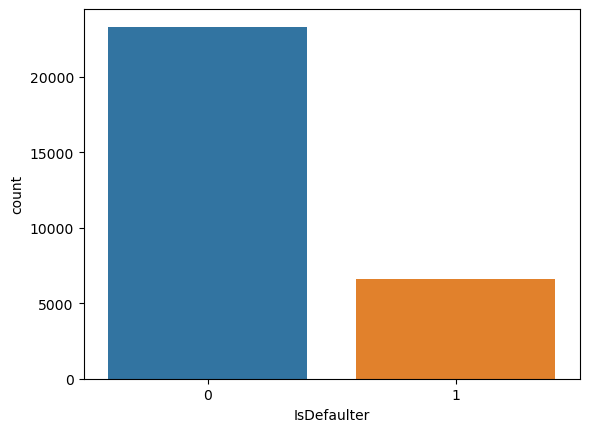

In [35]:
sns.countplot(df_cat,x='IsDefaulter')

<Axes: xlabel='SEX', ylabel='count'>

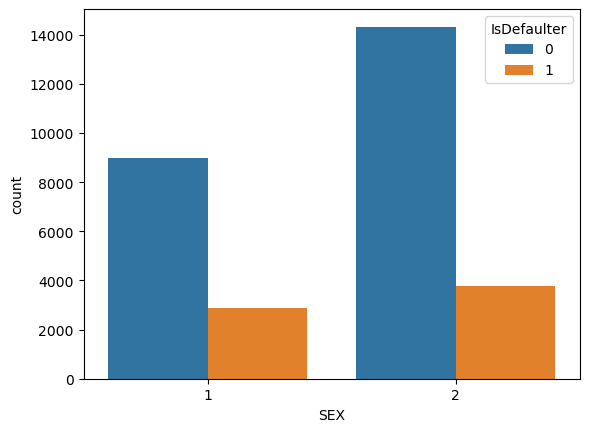

In [36]:
sns.countplot(df_cat,x='SEX',hue = 'IsDefaulter')

<Axes: xlabel='SEX', ylabel='count'>

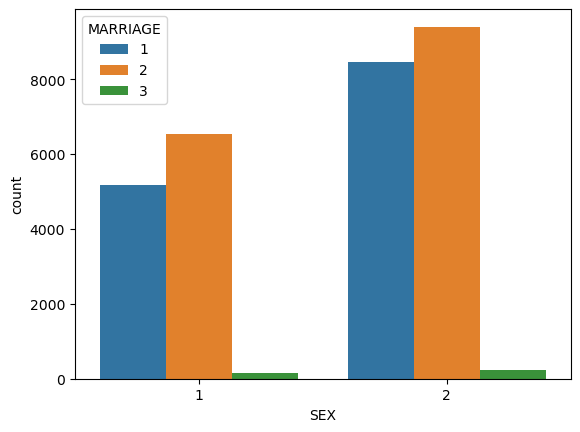

In [37]:
sns.countplot(df_cat,x='SEX',hue = 'MARRIAGE')

In [45]:
df_cat.replace({'SEX': {1 : 'MALE', 2 : 'FEMALE'}, 'EDUCATION' : {1 : 'graduate school', 2 : 'university', 3 : 'high school', 4 : 'others'}, 'MARRIAGE' : {1 : 'married', 2 : 'single', 3 : 'others'},'IsDefaulter':{0:'No', 1:'Yes'} }, inplace = True)

In [46]:
df_cat

,SEX,EDUCATION,MARRIAGE,IsDefaulter
ID,,,,
1,FEMALE,university,married,Yes
2,FEMALE,university,single,Yes
3,FEMALE,university,single,No
4,FEMALE,university,married,No
5,MALE,university,married,No
...,...,...,...,...
29996,MALE,high school,married,No
29997,MALE,high school,single,No
29998,MALE,university,single,Yes


In [47]:
df_edu = pd.crosstab(df_cat['EDUCATION'] , df_cat['IsDefaulter'])

In [48]:
df_edu

IsDefaulter,No,Yes
EDUCATION,,
graduate school,8531,2032
high school,3678,1237
others,435,33
university,10691,3328


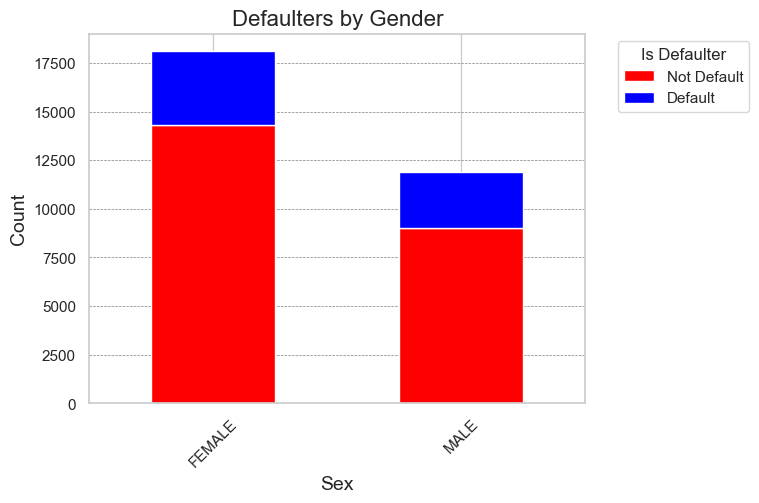

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a crosstab to get the counts of 'IsDefaulter' for each 'SEX' category
gender_crosstab = pd.crosstab(df_cat['SEX'], df_cat['IsDefaulter'])

# Set a color palette
colors = ["red", "blue"]

# Create a stacked bar plot
sns.set(style="whitegrid")
ax = gender_crosstab.plot(kind='bar', stacked=True, color=colors)

# Customize the plot
ax.set_title('Defaulters by Gender', fontsize=16)
ax.set_xlabel('Sex', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed

# Customize the legend and move it outside
legend_labels = ['Not Default', 'Default']
legend = plt.legend(legend_labels, title='Is Defaulter', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid lines
ax.yaxis.grid(which="both", color='gray', linestyle='--', linewidth=0.5)

plt.show()

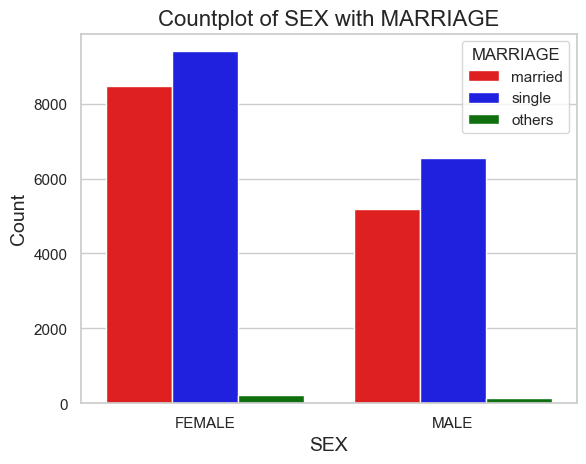

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the countplot with the specified colors
sns.set(style="whitegrid")  # Optional: Set the background style
sns.countplot(data=df_cat, x='SEX', hue='MARRIAGE', palette=['red', 'blue','green'])

# Customize the plot further if needed
plt.title('Countplot of SEX with MARRIAGE', fontsize=16)
plt.xlabel('SEX', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='MARRIAGE', title_fontsize='12')

# Show the plot
plt.show()


In [135]:
df_cat

,SEX,EDUCATION,MARRIAGE,IsDefaulter,Addition
ID,,,,,
1,FEMALE,university,married,Yes,2
2,FEMALE,university,single,Yes,3
3,FEMALE,university,single,No,2
4,FEMALE,university,married,No,1
5,MALE,university,married,No,1
...,...,...,...,...,...
29996,MALE,high school,married,No,1
29997,MALE,high school,single,No,2
29998,MALE,university,single,Yes,3


In [136]:
df_cat.groupby(['SEX', 'IsDefaulter'])['IsDefaulter'].count()

SEX     IsDefaulter
FEMALE  No             14330
        Yes             3761
MALE    No              9005
        Yes             2869
Name: IsDefaulter, dtype: int64

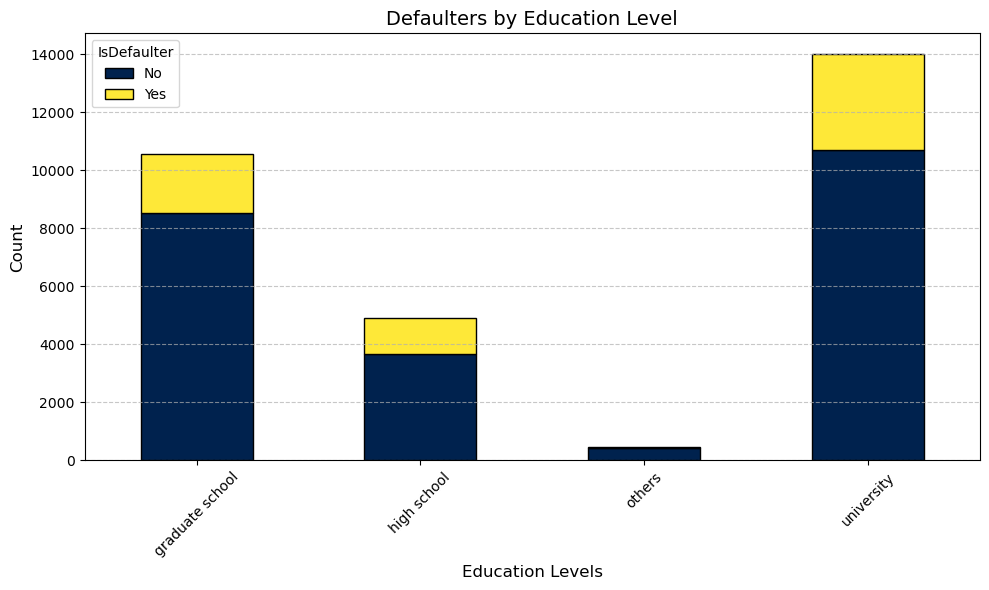

In [137]:
df_edu_plot = df_edu.plot(kind='bar', stacked=True, figsize=(10, 6), 
                          colormap='cividis', edgecolor='black')

# Customizing plot aesthetics
plt.xlabel('Education Levels', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Defaulters by Education Level', fontsize=14)
plt.legend(title='IsDefaulter', fontsize=10)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot with tight layout
plt.tight_layout()
plt.show()

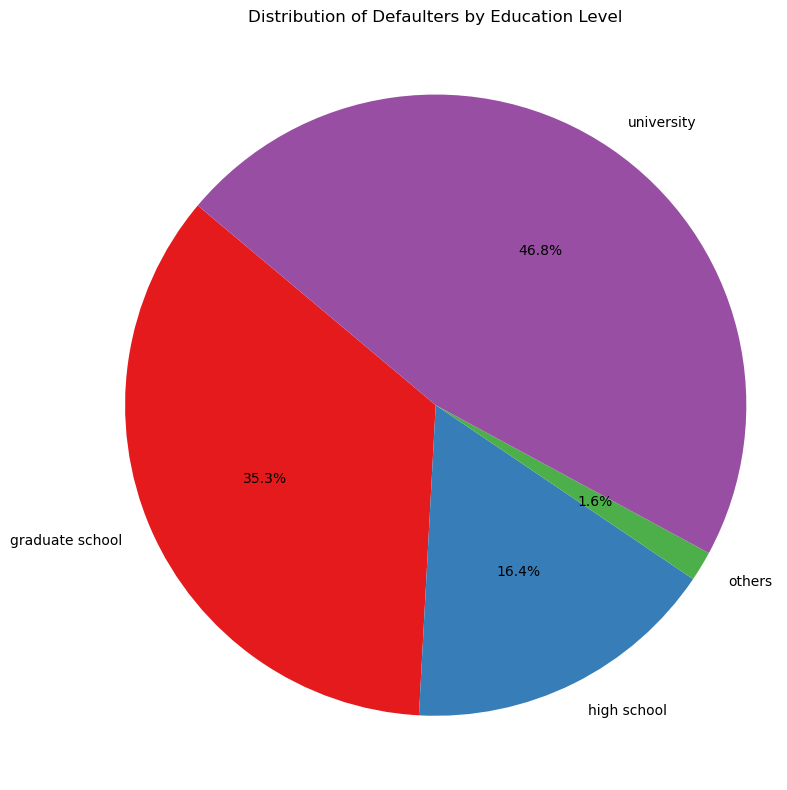

In [138]:
df_edu_total = df_edu.sum(axis=1)

# Plotting a pie chart
plt.figure(figsize=(8, 8))
plt.pie(df_edu_total, labels=df_edu_total.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Defaulters by Education Level')

# Show the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

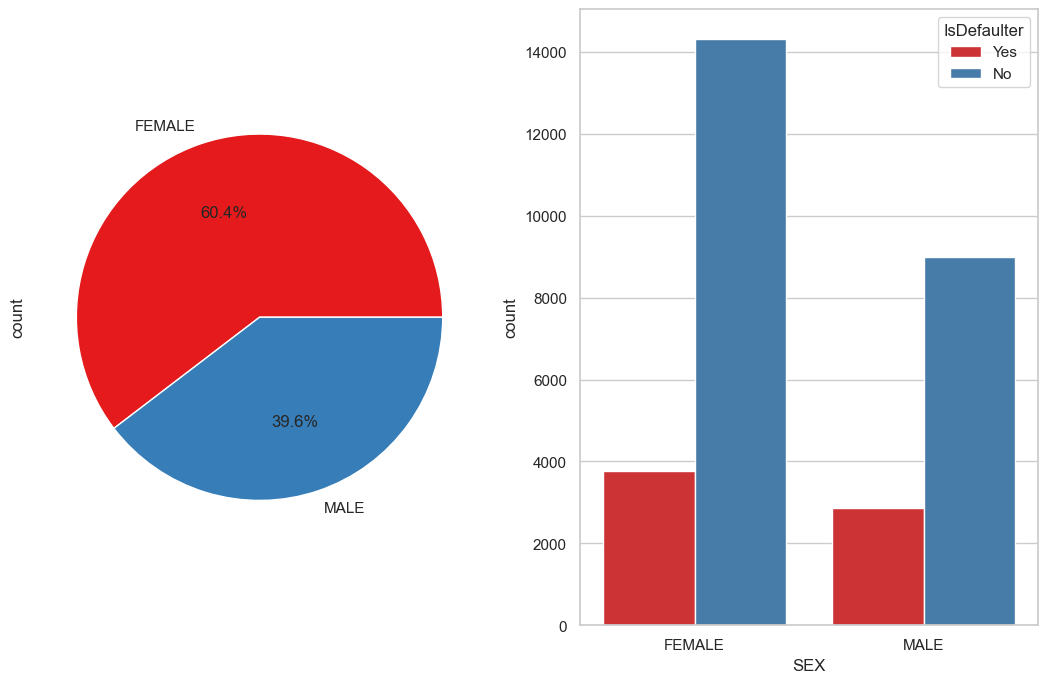

<Figure size 1000x500 with 0 Axes>

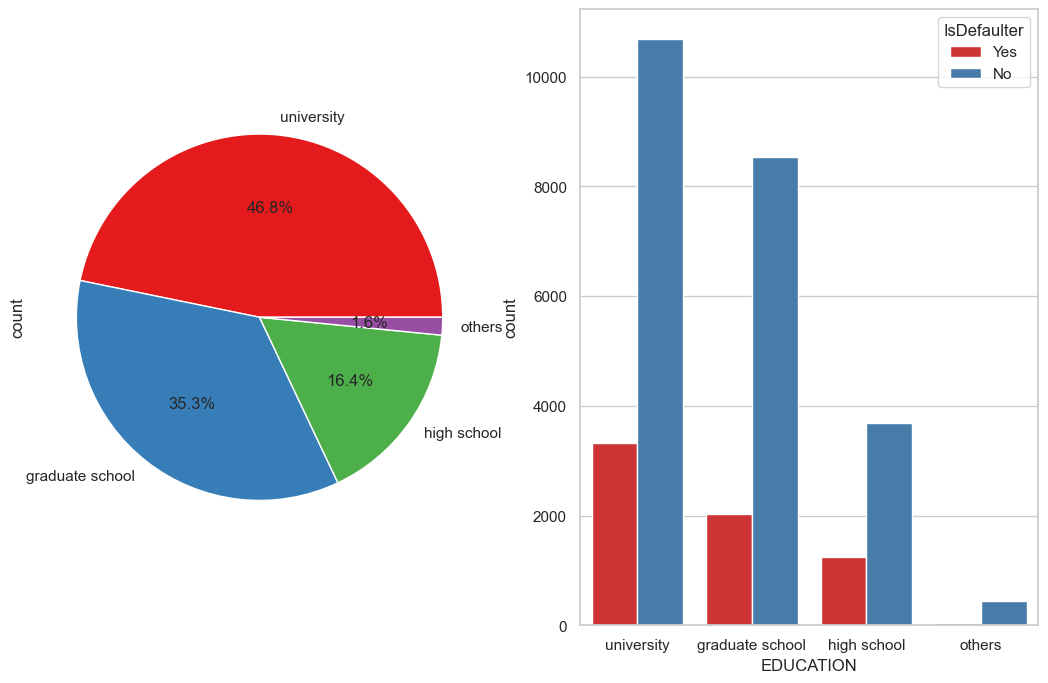

<Figure size 1000x500 with 0 Axes>

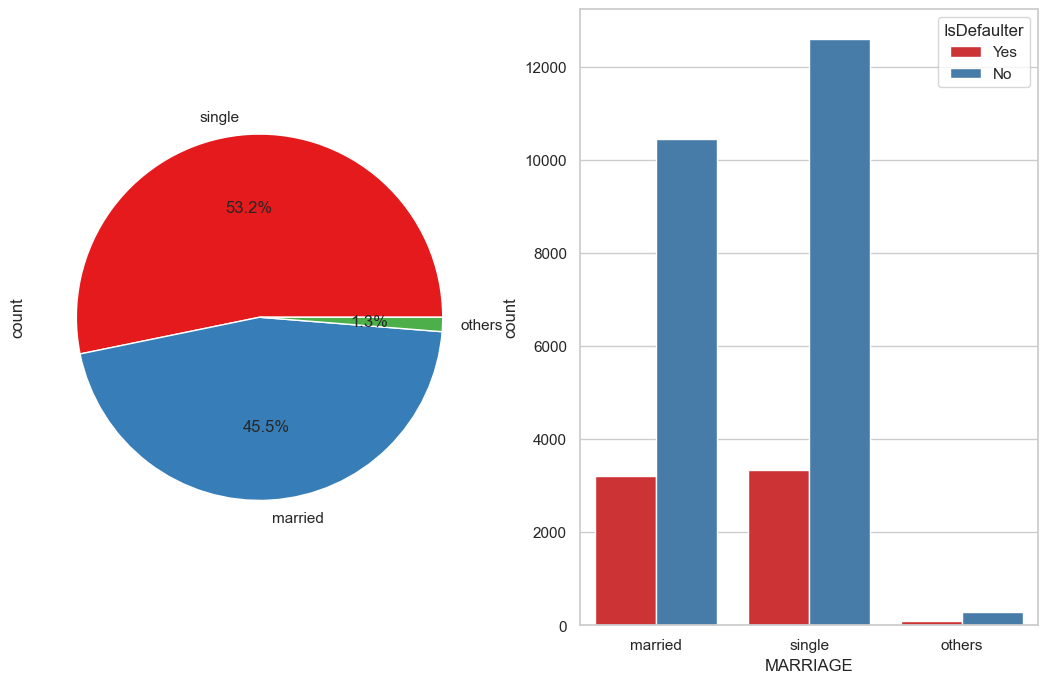

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the color palette for the countplot
sns.set_palette("Set1")

# Create a figure with subplots
plt.figure(figsize=(15, 6))
grid = plt.GridSpec(1, 3, wspace=0.4)

for col in cat_features:
    plt.figure(figsize=(10,5))
    fig, axes = plt.subplots(ncols=2,figsize=(13,8))
    df_cat[col].value_counts().plot(kind="pie",ax = axes[0],subplots=True,autopct='%1.1f%%')
    sns.countplot(x = col, hue = 'IsDefaulter', data = df_cat,)

In [139]:
pd.crosstab(df_cat['EDUCATION'] , df_cat['IsDefaulter'],normalize='index')

IsDefaulter,No,Yes
EDUCATION,,
graduate school,0.807630,0.192370
high school,0.748321,0.251679
others,0.929487,0.070513
university,0.762608,0.237392


In [141]:
#numerical var

In [142]:
df['LIMIT_BAL'].describe()

count      29965.000000
mean      167442.005006
std       129760.135222
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

<Axes: xlabel='LIMIT_BAL', ylabel='Count'>

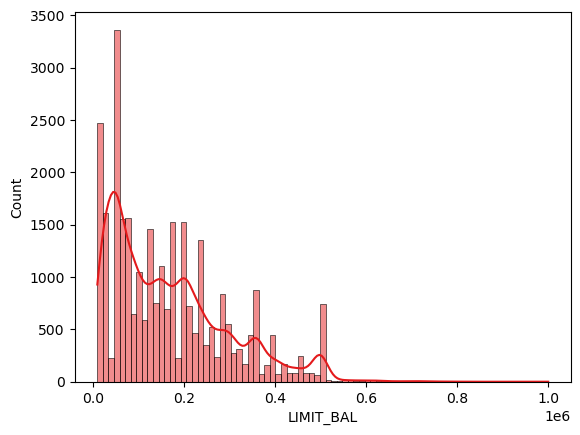

In [143]:
sns.histplot(df,x='LIMIT_BAL',kde=True)

In [144]:
df['LIMIT_BAL'].max()

1000000.0

In [145]:
df[df['LIMIT_BAL'] == df['LIMIT_BAL'].max()]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
ID,,,,,,,,,,,,,,,,,,,,,
2198,1000000.0,2,1,1,47,0,0,0,-1,0,...,891586.0,927171.0,961664.0,50784.0,50723.0,896040.0,50000.0,50000.0,50256.0,0


In [154]:
df[(df['LIMIT_BAL']>500000) & (df['IsDefaulter']==1)]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,IsDefaulter
ID,,,,,,,,,,,,,,,,,,,,,
452,600000.0,1,1,1,53,2,2,0,0,0,...,447130.0,440982.0,434715.0,0.0,18000.0,16000.0,16000.0,21000.0,20000.0,1
528,620000.0,2,2,1,45,2,2,0,0,0,...,163781.0,167159.0,170894.0,0.0,6200.0,6000.0,6000.0,6500.0,6000.0,1
2250,550000.0,2,2,1,32,0,0,0,0,0,...,530672.0,155083.0,165975.0,22863.0,167622.0,14000.0,4300.0,158064.0,28840.0,1
3340,550000.0,1,1,1,49,-1,-1,-1,-1,-1,...,18334.0,-114.0,-114.0,1522.0,1495.0,18426.0,0.0,0.0,22670.0,1
3403,710000.0,2,2,1,40,-2,-2,-2,-1,2,...,1004.0,854.0,8626.0,0.0,0.0,1004.0,0.0,8000.0,5000.0,1
4704,520000.0,1,3,1,41,2,2,0,0,0,...,251920.0,256512.0,262474.0,0.0,12620.0,8758.0,9047.0,9959.0,10500.0,1
5287,520000.0,2,1,2,33,0,0,0,0,0,...,168770.0,168964.0,191188.0,22000.0,18300.0,26500.0,30000.0,27000.0,25000.0,1
10896,630000.0,2,1,2,29,0,0,0,0,0,...,435019.0,329476.0,338557.0,15868.0,12371.0,26454.0,8510.0,11039.0,5390.0,1
12244,550000.0,2,1,2,34,-1,0,0,0,0,...,48244.0,36206.0,38021.0,3005.0,3004.0,4010.0,3002.0,3000.0,10010.0,1


<Axes: xlabel='IsDefaulter', ylabel='LIMIT_BAL'>

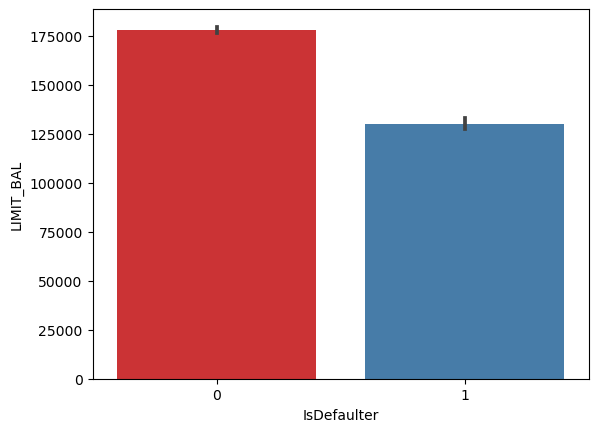

In [157]:
sns.barplot(x='IsDefaulter',y='LIMIT_BAL',data=df)

<Axes: xlabel='IsDefaulter', ylabel='LIMIT_BAL'>

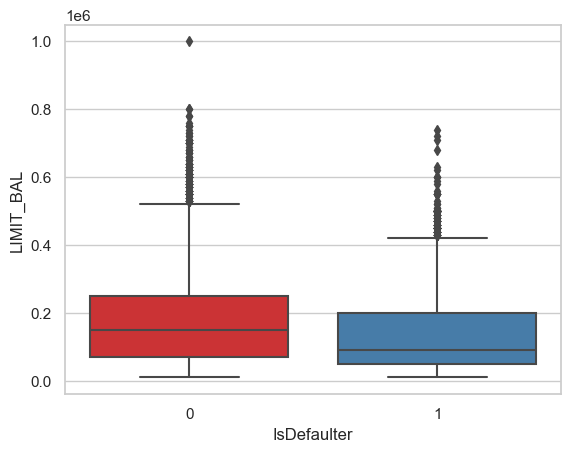

In [54]:
sns.boxplot(x=df['IsDefaulter'], y=df['LIMIT_BAL'])

In [160]:
df['AGE'].mean()

35.487969297513764

In [164]:
df.groupby(['IsDefaulter'])['AGE'].mean()

IsDefaulter
0    35.421041
1    35.723529
Name: AGE, dtype: float64

In [163]:
df[['AGE','IsDefaulter']]

,AGE,IsDefaulter
ID,,
1,24,1
2,26,1
3,34,0
4,37,0
5,57,0
...,...,...
29996,39,0
29997,43,0
29998,37,1


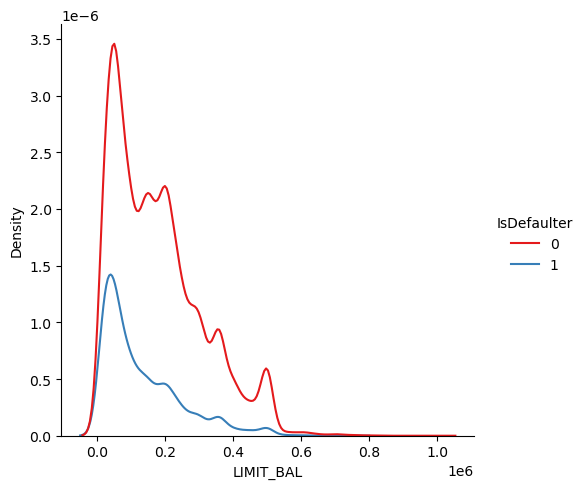

In [171]:
sns.displot(data=df,x='LIMIT_BAL', hue='IsDefaulter',kind='kde')

In [ ]:
#plt.pie(df['AGE'])